In [1]:
import uproot as up
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection
%matplotlib inline


In [2]:
file=up.open("/home/rice/Projects/DUNE_Opticks/Build_Test/work/100k_17-3Voxel_Comparison.root")

G4=file["pmtresponse/PhotonLibraryData"]
print(G4.keys())

G4Voxel=G4["Voxel"].array().to_numpy()
G4SensorID=G4["OpChannel"].array().to_numpy()
G4Visibility=G4["Visibility"].array().to_numpy()

['Voxel', 'OpChannel', 'Visibility']


In [3]:

#f=up.open("/home/rice/Projects/DUNE_Opticks/OlderG4OpticksGDML/dune10kt_v5_refactored_1x2x6_e_3GeV.root")
O=file["opticks/Visibilities"]
print(O.keys())
OVoxel=O["Voxel"].array().to_numpy()
OSensorID=O["OptDetID"].array().to_numpy()
OVisibility=O["Visibility"].array().to_numpy()
OhitSensID=file["opticks/OpticksHits/sensor_id"].array().to_numpy()

['Voxel', 'OptDetID', 'Visibility']


In [4]:
print(len(G4Voxel))
print(len(OVoxel))
print(1-len(G4Voxel)/len(OVoxel))


1205256
1150660
-0.04744755183981364


Text(0.5, 0, 'Visibility')

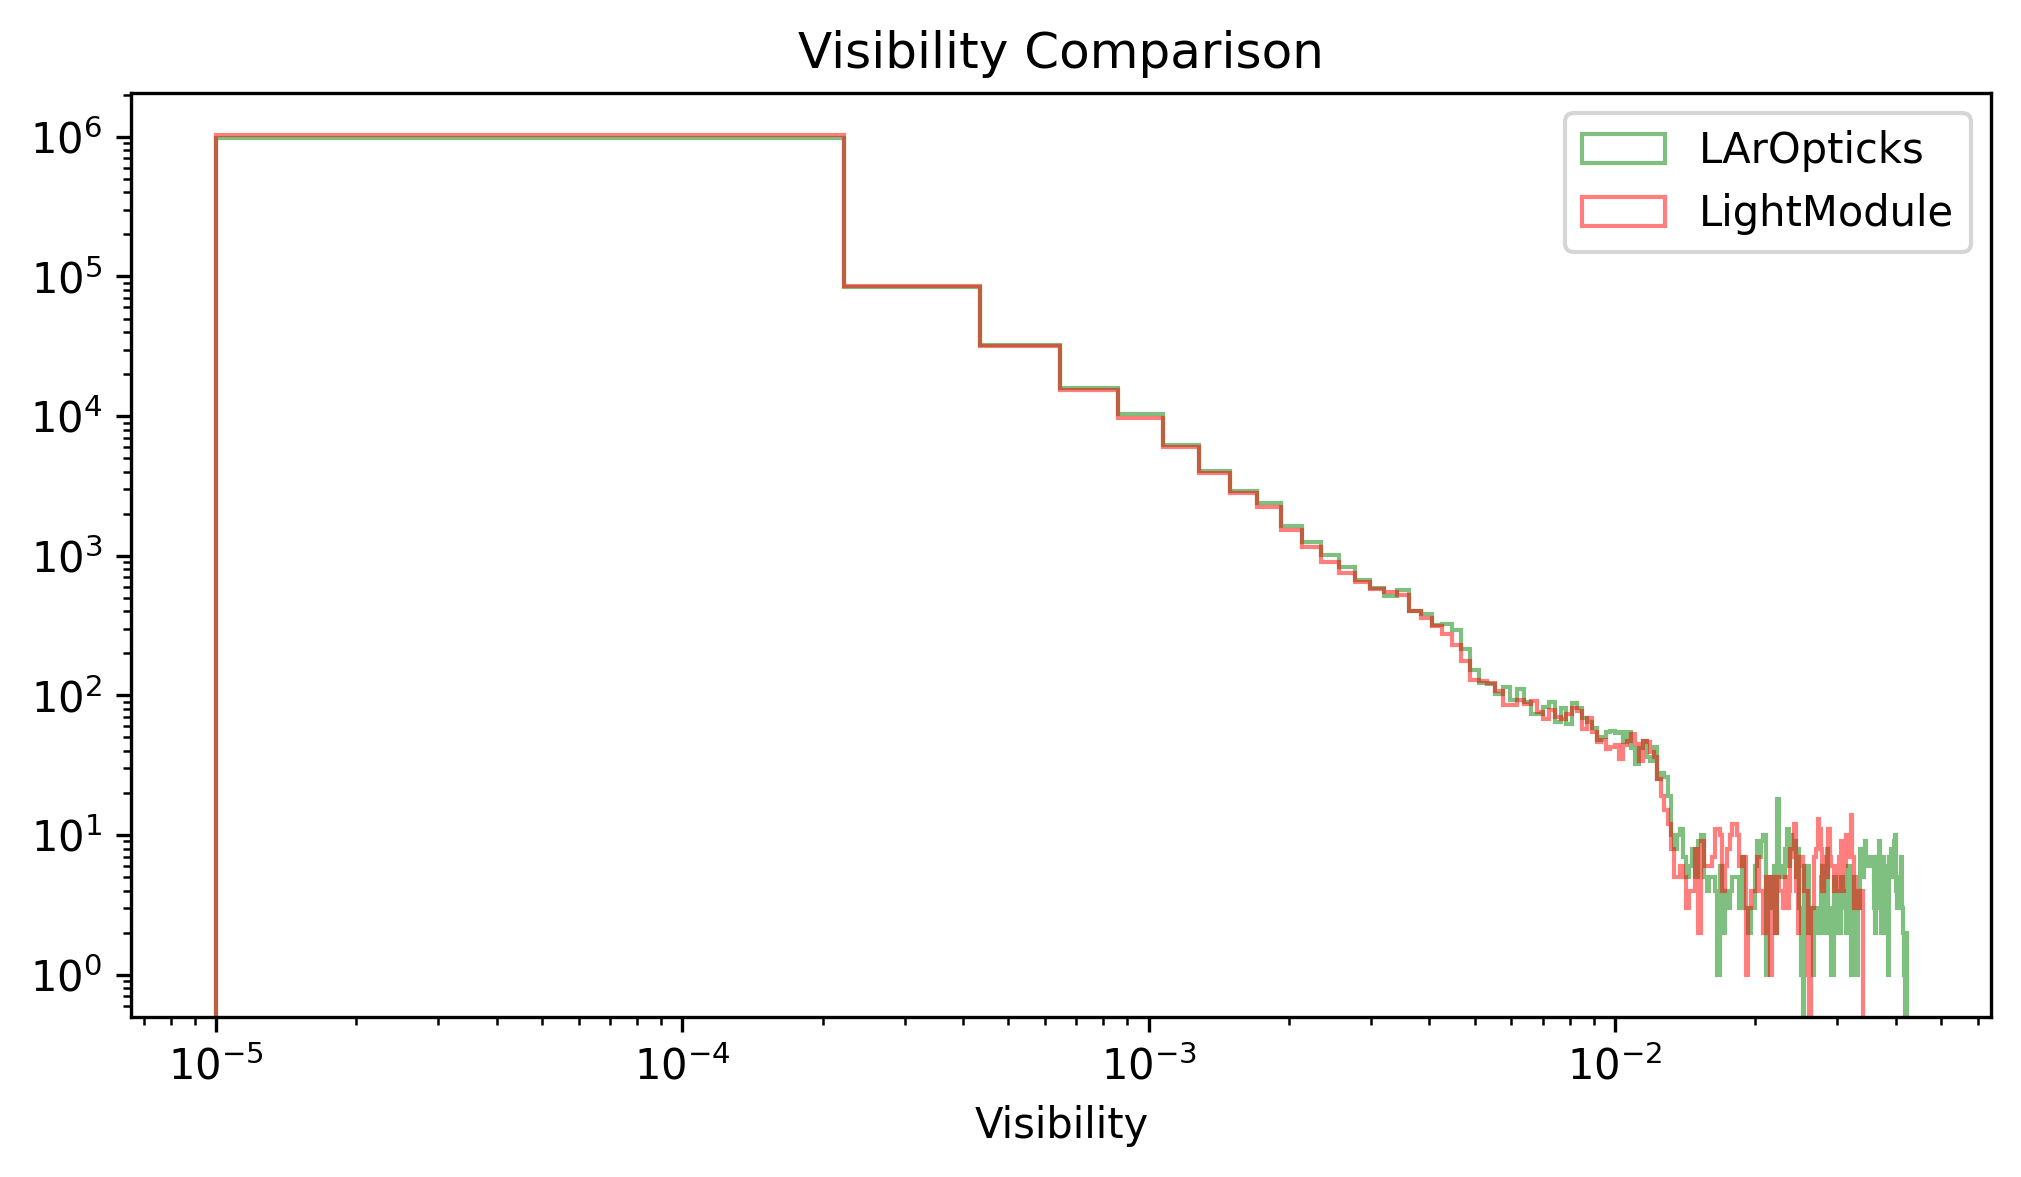

In [17]:
vismin = min(OVisibility.min(), G4Visibility.min())
vismax = max(OVisibility.max(), G4Visibility.max())
xbins = np.linspace(vismin , vismax , 200)

plt.figure(figsize=(8,4),dpi=300)
plt.title("Visibility Comparison")
plt.hist(OVisibility, bins=xbins, alpha=0.5, label="LArOpticks",histtype="step",color="green")
plt.hist(G4Visibility, bins=xbins, alpha=0.5, label="LightModule",histtype="step",color="red")
plt.legend()
plt.loglog()
#plt.semilogy()
plt.xlabel("Visibility")

Text(0.5, 0, 'SensorID')

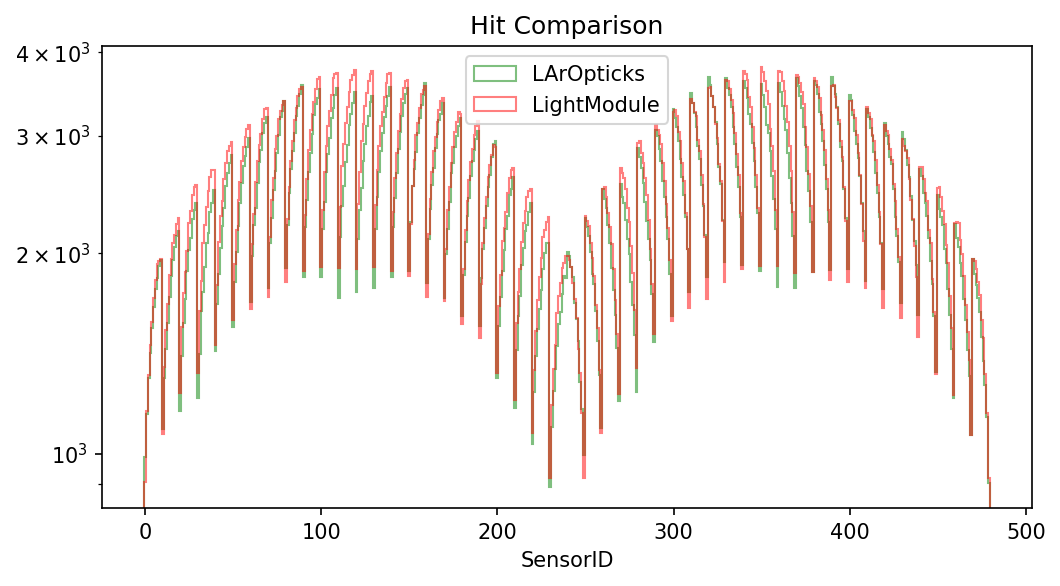

In [6]:
vismin = min(OSensorID.min(), G4SensorID.min())
vismax = max(OSensorID.max(), G4SensorID.max())
xbins = np.arange(vismin-0.5 , vismax+1.5 , 1)
plt.figure(figsize=(8,4),dpi=150)
plt.title("Hit Comparison")
plt.hist(OSensorID, bins=xbins, alpha=0.5, label="LArOpticks",histtype="step",color="green")
plt.hist(G4SensorID, bins=xbins, alpha=0.5, label="LightModule",histtype="step",color="red")
#plt.hist(OhitSensID, bins=xbins, alpha=0.5, label="Optickshits")
plt.legend()
plt.semilogy()
plt.xlabel("SensorID")


In [7]:
ox=file["opticks/OpticksHits/x"].array().to_numpy()
oy=file["opticks/OpticksHits/y"].array().to_numpy()
oz=file["opticks/OpticksHits/z"].array().to_numpy()
osid=file["opticks/OpticksHits/sensor_id"].array().to_numpy()
owavelength=file["opticks/OpticksHits/wavelength"].array().to_numpy()

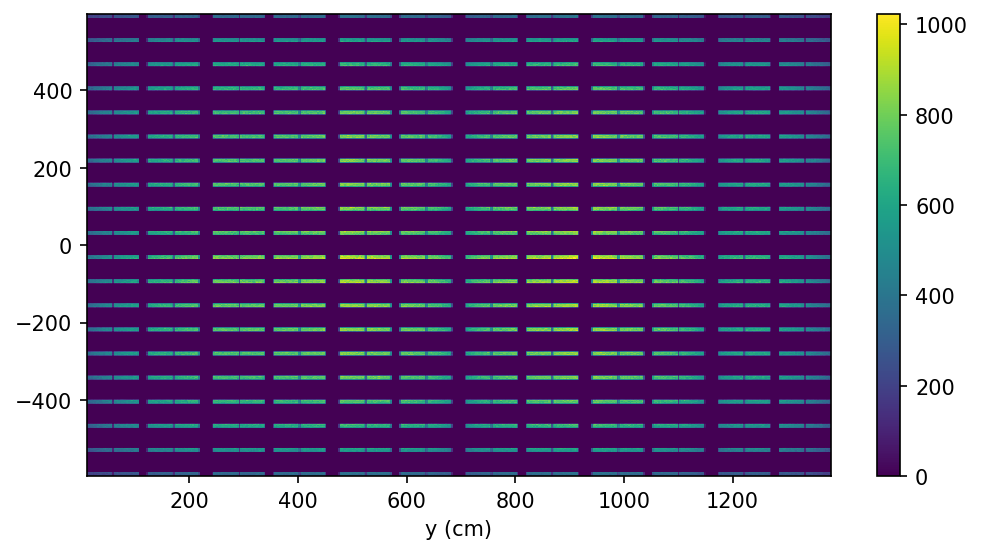

In [8]:
plt.figure(figsize=(8,4),dpi=150)
_=plt.hist2d(oz/10,oy/10,bins=500,cmin=0,cmax=2000)
plt.xlabel("z (cm)")
plt.xlabel("y (cm)")
plt.colorbar();

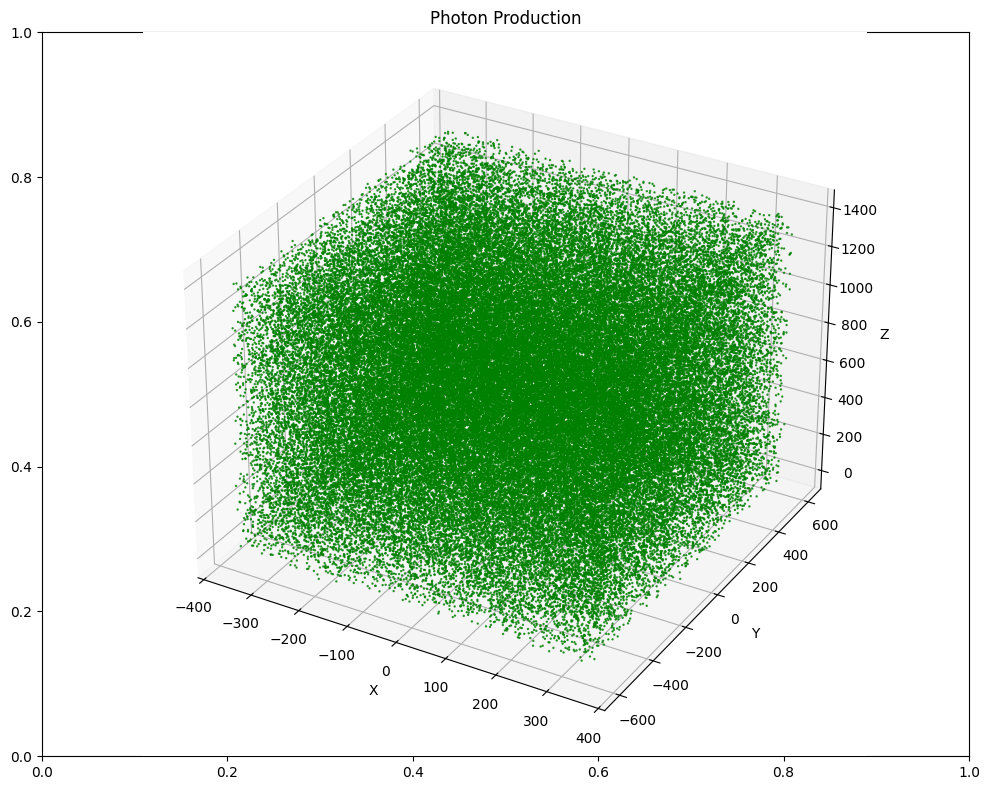

In [9]:

initPhotons=file["generator/PhotonsGenerated"]
# load and flatten arrays
x = np.asarray(initPhotons["X"].array(library="np")).ravel()
y = np.asarray(initPhotons["Y"].array(library="np")).ravel()
z = np.asarray(initPhotons["Z"].array(library="np")).ravel()

# mask and downsample
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
pts = np.vstack((x[mask], y[mask], z[mask])).T
N = 100000  # keep this <= 100k for reasonable speed
if pts.shape[0] > N:
    idx = np.random.choice(pts.shape[0], N, replace=False)
    pts = pts[idx]

fig = plt.figure(figsize=(10,8))
plt.title("Photon Production")
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=0.5, color="green", alpha=0.8)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
#plt.colorbar(sc, label='Z')
plt.tight_layout()
plt.savefig('cloud_3d.png', dpi=200)  # offscreen-friendly
plt.show()


In [10]:
OHits=file["opticks/OpticksHits"]

print(OHits.keys())
evts=OHits["evtID"].array().to_numpy()
SIDs=OHits["sensor_id"].array().to_numpy()

['evtID', 'hit_id', 'parent_id', 'sensor_id', 'x', 'y', 'z', 't', 'px', 'py', 'pz', 'mx', 'my', 'mz', 'wavelength', 'boundary']


In [11]:
PhotonGen=file["opticks/photon_gen"]
PhotonGenEvts=PhotonGen["evtID"]
PhotonGenEvtIDs,PhotonGencounts=np.unique(PhotonGenEvts,return_counts=True)


In [12]:
uniqueEvtIDs,counts=np.unique(evts,return_counts=True)
uniqueSIDs,Sidcounts=np.unique(SIDs,return_counts=True)

In [13]:
## External Visibility Computation

Visibility = {}
VisArray = np.array([])
SID = np.array([])
for evt in uniqueEvtIDs:
    eventMask=evt==evts
    MaskedEvents=evts[eventMask]
    MaskedSIds=SIDs[eventMask]
    uniqueSIDs,Sidcounts=np.unique(MaskedSIds,return_counts=True)
    vis=Sidcounts/PhotonGencounts[0]
    Visibility[evt]=[uniqueSIDs,vis]
    VisArray=np.append(VisArray,vis)
    SID=np.append(SID,uniqueSIDs)

Text(0.5, 0, 'Visibility')

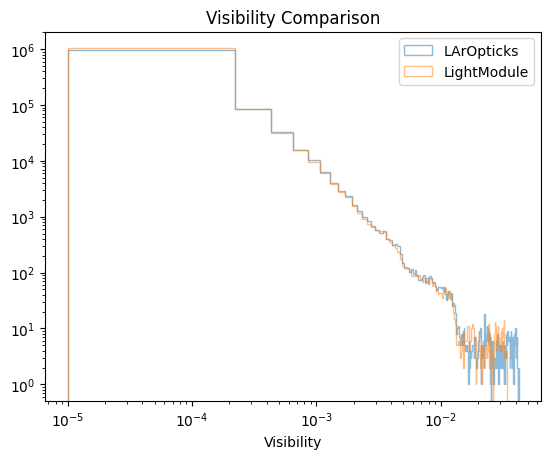

In [14]:
vismin = min(OVisibility.min(), G4Visibility.min())
vismax = max(OVisibility.max(), G4Visibility.max())
xbins = np.linspace(vismin , vismax , 200)
plt.title("Visibility Comparison")
plt.hist(OVisibility, bins=xbins, alpha=0.5, label="LArOpticks",histtype="step")
plt.hist(G4Visibility, bins=xbins, alpha=0.5, label="LightModule",histtype="step")
plt.legend()
plt.loglog()
plt.xlabel("Visibility")

Text(0.5, 0, 'Visibility')

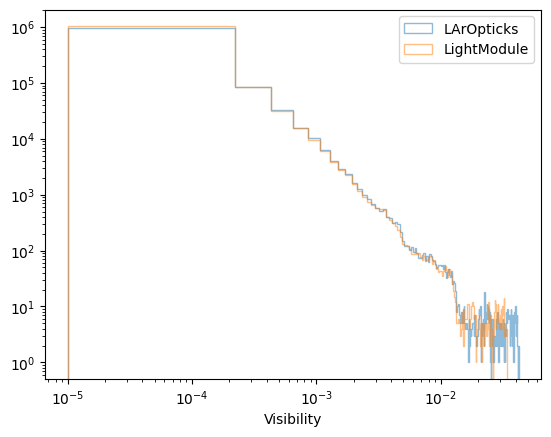

In [15]:
vismin = min(VisArray.min(), G4Visibility.min())
vismax = max(VisArray.max(), G4Visibility.max())
xbins = np.linspace(vismin , vismax , 200)
_=plt.hist(VisArray, bins=xbins, alpha=0.5, label="LArOpticks",histtype="step")
_=plt.hist(G4Visibility, bins=xbins, alpha=0.5, label="LightModule",histtype="step")
plt.legend()
plt.loglog()
plt.xlabel("Visibility")

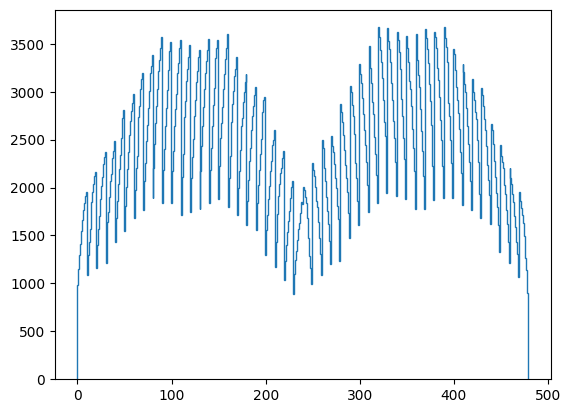

In [16]:
_=plt.hist(SID,bins=480,histtype="step")
